# MAE 223 — Tutorial: SAFARI Sea Surface Temperature

## Background

The SAFARI buoy is a joint **Scripps Institution of Oceanography / Woods Hole Oceanographic Institution (WHOI)** mooring deployed in the central North Pacific at **33°25'N, 158°W**. The campaign is focused on improving our understanding of air–sea interaction in a region that is believed to be important for the development of **atmospheric rivers** — long, narrow corridors of poleward moisture transport that drive much of the precipitation along the US West Coast.

Ocean surface temperature is a key variable in air–sea interaction. Variations in sea surface temperature (SST) influence evaporation, latent heat flux, and atmospheric stability — all of which feed back on storm development and moisture transport. Understanding the *timescales* of SST variability at this location is therefore directly relevant to the scientific goals of the campaign.

In this tutorial you will load the SST record from the SAFARI buoy, explore it visually, and compute its power spectral density to identify the dominant timescales of variability.

---

**The `spectrumCB` function is defined in the next cell. Run it before proceeding.**

In [3]:
import numpy as np
from scipy.signal import detrend as scipy_detrend


def spectrumCB(time, data, chunk):
    """
    Compute a one-sided Power Spectral Density (PSD) using Welch's method:
    50% overlapping segments, linear detrending, FFT, and ensemble averaging.

    Parameters
    ----------
    time  : array-like  — time in decimal days
    data  : array-like  — data values, NaN-free
    chunk : int         — samples per segment

    Returns
    -------
    f        : ndarray  — one-sided frequency vector [cpd]
    a        : ndarray  — averaged PSD [units² / cpd]
    parseval : float    — ratio ∫PSD df / var(data); should be ≈ 1.0
    """
    data  = np.asarray(data,  dtype=float)
    time  = np.asarray(time,  dtype=float)
    chunk = int(chunk)

    # split into 50% overlapping segments
    segments = []
    step = chunk // 2
    ind  = 0
    while ind + chunk <= len(data):
        segments.append(data[ind : ind + chunk])
        ind += step

    # frequency vector
    dt = np.nanmean(np.diff(time))
    fn = 1.0 / (2.0 * dt)
    N  = chunk
    df = 1.0 / (dt * N)
    f  = np.arange(0, fn + df / 2, df)
    nf = len(f)

    # compute and average PSD
    A = np.empty((len(segments), nf))
    for i, seg in enumerate(segments):
        seg_dt   = scipy_detrend(seg)
        fft_vals = np.fft.fft(seg_dt)
        amp = np.abs(fft_vals[:nf]) ** 2
        amp = amp / N ** 2
        amp = amp * 2
        amp = amp / df
        A[i] = amp
    a = A.mean(axis=0)

    # Parseval check
    variance = np.nanstd(data) ** 2
    parseval = np.trapezoid(a, f) / variance
    print(f"  Segments used:  {len(segments)}")
    print(f"  Parseval check: {parseval:.4f}  (ideal = 1.00)")
    return f, a, parseval


## Exercise 1 — Load and Inspect the Data

Load `safari_sst.json` and print the metadata. Then extract the timestamps and SST values.

The file has three keys: `'metadata'`, `'time'`, and `'sst'`. Timestamps are ISO 8601 strings (`'%Y-%m-%dT%H:%M'`). SST is in degrees Celsius, sampled hourly with no missing values.

In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Load the data
with open('safari_sst.json') as f:
    safari = json.load(f)

# YOUR CODE HERE — print the metadata
print('Metadata:')
for key, value in safari['metadata'].items():
    print(f'  {key}: {value}')


# YOUR CODE HERE — parse timestamps into decimal days since the record start
# Hint: same pattern as the demo notebook
#   1. Parse each string with datetime.strptime(s, '%Y-%m-%dT%H:%M')
#   2. Subtract the first timestamp
#   3. Convert to days via .total_seconds() / 86400
# Store result as: time_sst  (decimal days)
time_dt = [datetime.strptime(t, '%Y-%m-%dT%H:%M') for t in safari['time']]
t0 = time_dt[0]
time_sst = np.array([(t - t0).total_seconds() / 86400 for t in time_dt], dtype=float)

# YOUR CODE HERE — extract SST as a numpy float array
# Store result as: sst  (degrees C)
sst = np.array(safari['sst'], dtype=float)

# YOUR CODE HERE — print a summary: record length, dt, SST range
dt = np.mean(np.diff(time_sst))

print('\nSummary:')
print(f'  Record length: {len(sst)} samples')
print(f'  dt: {dt:.6f} days')
print(f'  SST range: {np.min(sst):.2f} to {np.max(sst):.2f} deg C')

Metadata:
  source: SAFARI 2025 buoy — Scripps Institution of Oceanography / WHOI joint mooring
  location: 33 25 N, 158 W (central North Pacific)
  instrument: SeaBird SBE37 CTD
  variable: Near-surface ocean temperature
  units: degrees C
  start: 2025-11-20T23:00
  end: 2026-04-02T14:00
  n_samples: 3184
  n_nulls: 0
  dt_hours: 1.0

Summary:
  Record length: 3184 samples
  dt: 0.041667 days
  SST range: 15.76 to 21.28 deg C


## Exercise 2 — Plot the Full SST Time Series

Plot the entire SST record against time. Label your axes and give the plot a descriptive title.

Look at the record carefully before moving on:
- What is the overall trend?
- Can you see variability at multiple timescales?
- Are there any obvious events or anomalies?

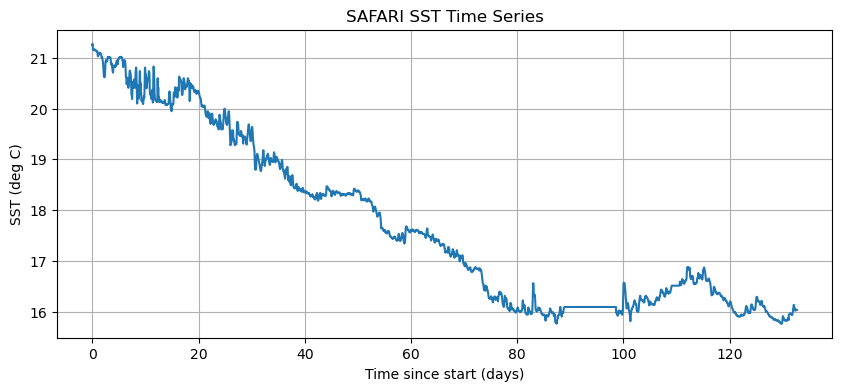

In [7]:
# YOUR CODE HERE — plot the full SST time series
# Include: axis labels, title, grid
# plot the full SST time series
plt.figure(figsize=(10, 4))
plt.plot(time_sst, sst)
plt.xlabel('Time since start (days)')
plt.ylabel('SST (deg C)')
plt.title('SAFARI SST Time Series')
plt.grid(True)
plt.savefig('sst_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# The record shows a strong overall cooling trend from about 21.2 to 16 C.
# This likely reflects seasonal cooling from late autumn into spring.
# Superimposed on this trend are shorter fluctuations on timescales of several days to weeks.
# There are also small higher-frequency variations that may be associated with weather events or diurnal variability.

## Exercise 3 — Compute the Power Spectral Density

Compute the PSD of the SST record using `spectrumCB`.

You must choose the number of chunks. Think about:
- How long is the record?
- What timescales of variability do you want to resolve?
- How many segments do you need for a stable estimate?

State your choice and justify it in a comment.

In [10]:
# YOUR CODE HERE — choose num_chunks and justify your choice in a comment
num_chunks = 4   # YOUR CODE HERE

# YOUR CODE HERE — compute chunk size, segment length, and df, then print them
chunk = len(sst) // num_chunks
segment_days = chunk * dt
df = 1.0 / (chunk * dt)

print(f'Number of samples = {len(sst)}')
print(f'num_chunks = {num_chunks}')
print(f'chunk = {chunk} samples')
print(f'segment length = {segment_days:.2f} days')
print(f'df = {df:.4f} cpd')

# YOUR CODE HERE — call spectrumCB
# Store outputs as: f_sst, psd_sst, parseval_sst
f_sst, psd_sst, parseval_sst = spectrumCB(time_sst, sst, chunk)

Number of samples = 3184
num_chunks = 4
chunk = 796 samples
segment length = 33.17 days
df = 0.0302 cpd
  Segments used:  7
  Parseval check: 0.0150  (ideal = 1.00)


## Exercise 4 — Plot the Spectrum and Identify Peaks

Plot the PSD on a log-log scale. Then add at least one vertical reference line at a frequency of your choosing.

**You must identify at least one peak in the spectrum.** For each peak you identify:
1. State the frequency (cpd) and corresponding period (days or hours)
2. Propose a physical mechanism that could drive SST variability at that timescale

There is no single correct answer — the goal is to reason from the physics.

Peak frequency = 1.085 cpd
Period = 0.92 days = 22.1 hr


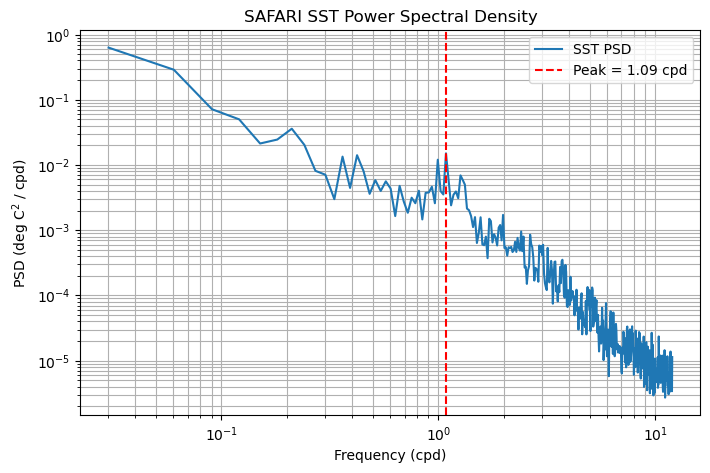

In [21]:
# YOUR CODE HERE — plot the SST PSD on a log-log scale
# Include: axis labels, title, grid, at least one reference line
# plot the SST PSD on a log-log scale

# find the peak between 0.5-2.0
mask = (f_sst > 0.5) & (f_sst < 2.0)

i_peak = np.argmax(psd_sst[mask])
f_peak = f_sst[mask][i_peak]
T_peak_days = 1 / f_peak
T_peak_hours = 24 / f_peak

print(f'Peak frequency = {f_peak:.3f} cpd')
print(f'Period = {T_peak_days:.2f} days = {T_peak_hours:.1f} hr')


fig, ax = plt.subplots(figsize=(8, 5))

ax.loglog(f_sst[1:], psd_sst[1:], label='SST PSD')
ax.axvline(f_peak, color='r', linestyle='--',
           label=f'Peak = {f_peak:.2f} cpd')

ax.set_xlabel('Frequency (cpd)')
ax.set_ylabel('PSD (deg C$^2$ / cpd)')
ax.set_title('SAFARI SST Power Spectral Density')
ax.grid(True, which='both')
ax.legend()

fig.savefig('sst_psd.png', dpi=300, bbox_inches='tight')
plt.show()

## Reflection

Answer the following in the cell below.

**Q1.** How many chunks did you choose and why? What frequency resolution did that give you?

**Q2.** Identify at least one spectral peak. What is its frequency and period? What physical process do you think drives SST variability at that timescale at this location in the North Pacific?

**Q3.** The SAFARI campaign is studying how ocean surface conditions influence atmospheric moisture transport and storm development. Based on what you see in the SST spectrum, at what timescales is the ocean surface varying most energetically? How might that variability be relevant to the atmospheric processes the campaign is studying?

**Your answers:**

Q1:
I chose 4 chunks. The record is only about 133 days long, so I wanted each segment to still be fairly long, but also have enough segments to average together. With 4 chunks, each segment is about 33 days long. The frequency resolution was about 0.030 cpd.

Q2:
One clear peak occurs at about 1.09 cpd, corresponding to a period of about 0.92 days or 22 hours. This is close to the daily timescale, so I think it is mainly caused by the daily heating and cooling cycle of the ocean surface.

Q3:
The SST varies most strongly at low frequencies, especially on timescales of about 10–30 days. That means the ocean surface is changing most at the same timescale as storms and larger weather patterns. These slower SST changes could affect how much moisture and heat move from the ocean into the atmosphere, which may influence storm development during SAFARI.